In [185]:
# This python notebook is for a hands-on tutorial on the conception of pulsar search, the material is developed by Prof. Jason Hessels of U. Amsterdam and McGill
# I also modified a python notebook solution provided by Dr. Ziggy Pleunis (UvA/ASTRON) 

In [186]:
#The first part of this notebook is about finding out the spin frequency of the original pulsar PSR B1919+21 (the first one found by Jocelyn Bell) using Fourier Transform
#The input file is a dedispersed timeseries of this pulsar taken by the LOFAR radio telecope
#You might have already downloaded this file in the class. but for completeness I am including this cell for download

import requests

url = "https://raw.githubusercontent.com/cherryng/teaching/main/L197621_SAP0_BEAM1_DM12.44_Mask.dat"

filename = url.split("/")[-1]  # keeps original name

r = requests.get(url)

with open(filename, "wb") as f:
    f.write(r.content)

print(f"Saved as {filename}")



Saved as L197621_SAP0_BEAM1_DM12.44_Mask.dat


In [187]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

#Read file to get the time series (ts)
ts = np.fromfile("L197621_SAP0_BEAM1_DM12.44_Mask.dat", dtype=np.float32)

#Check the length of the time series to find out the total number of samples. 
nsamp = len(ts)

#The sampling rate of this observation
tsamp = 0.00262143998406827

#The integration time (t)
t = np.arange(nsamp) * tsamp

print('nsamp',nsamp)
print('integration time', nsamp*tsamp,'s')

nsamp 69120
integration time 181.19393169879882 s


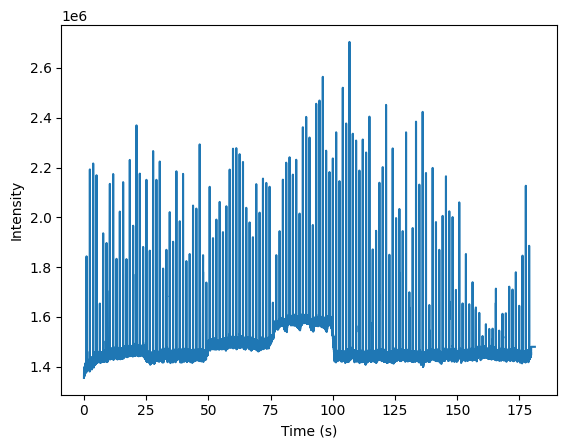

In [188]:
# check data
plt.plot(t, ts)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")
plt.show()


Text(0.5, 0, 'Time (s)')

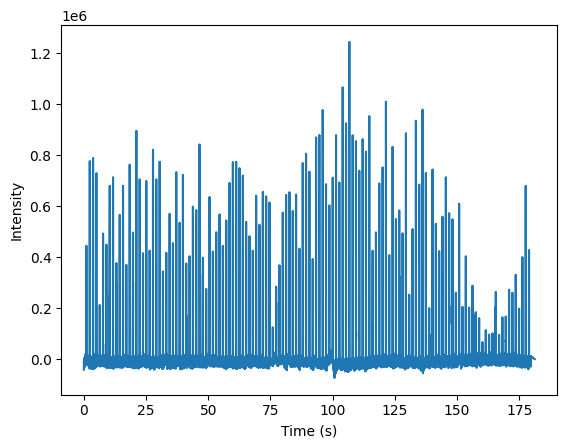

In [75]:
# The baseline of this time series is not flat, we will need to filter out this red noise
# Hint: use scipy.ndimage.uniform_filter1d to calculate a running mean in order to normalize the data
# Hint: need to play with window size when data and/or tsamp changes

running_mean = scipy.ndimage.uniform_filter1d(ts, size=1000)
normalized = ts-running_mean
plt.plot(t, normalized)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")

spin freq 0.747775368279369


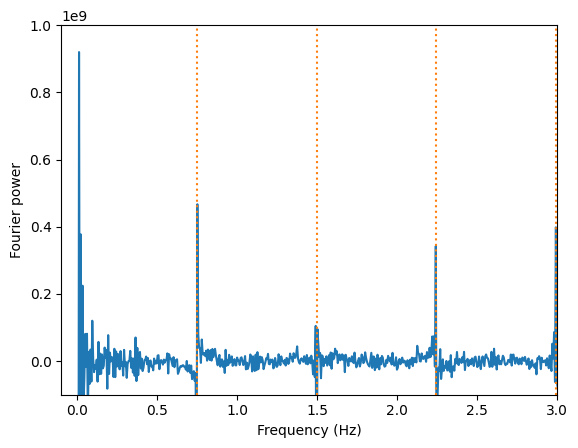

In [83]:
# Run a Fourier transform on the time series ts to find any periodicity in the data
# Hint: use np.fft.rfft and np.fft.rfftfreq
fft = np.fft.rfft(ts)[1:]
xf = np.fft.rfftfreq(n=ts.size, d=tsamp)[1:]
plt.plot(xf, fft)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")


# Add to the plot the spin period of PSR B1919+21 to see if they match up
# Hint: get the spin period in seconds from the internet, e.g. the ATNF catalog https://www.atnf.csiro.au/research/pulsar/psrcat/
p0 = 1.3373
f0 = 1 / p0
print('spin freq', f0)

# plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlim(-0.1, 3)
plt.ylim(-0.1e9, 1e9)

plt.show()

In [77]:
# The giant peak near 0 Hz is the DC component
# It is there because the total intensity in our data is always positive, 
# the baseline noise has nonzero mean, and we did not subtract the mean.
# Just ignore that for now, and print the next peak (which should also conincide with the orange lines)
# In order to get the spin frequency

x = 10  # number of largest values
idx = np.argsort(fft)[-x:]   # indices of largest x values
print(idx)
print(xf[idx])    

idx_peak = 8
f0_fft = xf[idx[8]]
print('spin freq from FFT is', f0_fft)

[2032 1218  405    3  541 1354 1760  135 1896    1]
[1.12200226e+01 6.72759837e+00 2.24069314e+00 2.20757945e-02
 2.99127015e+00 7.47817539e+00 9.71886853e+00 7.50577013e-01
 1.04694455e+01 1.10378972e-02]
spin freq from FFT is 10.469445539453327


number of time bins (y axis in inshow) 91
number of phase bins (x axis in imshow) 256


/var/folders/g4/9xmh6cjn4zn7r24hvcfswgz1wj7pk0/T/ipykernel_61353/1243909889.py:44: RuntimeWarning: invalid value encountered in divide
  data = data_sum / data_count


Text(0.5, 0, 'Phase')

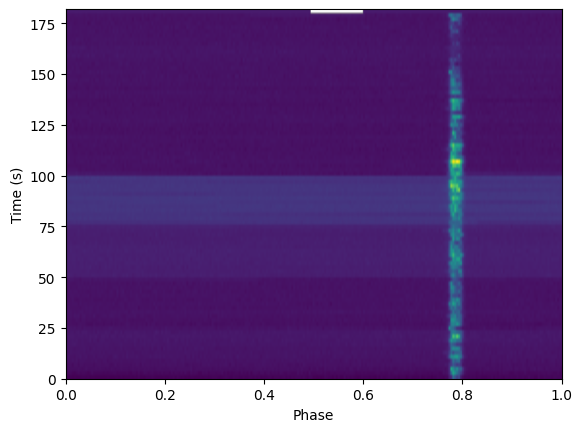

In [78]:
# create a dynamic profile of time in y and phase in x

# Try different tsub factors and see how that changes the resolution of the profile
# This is like saying we will average over every 'tsub' seconds of data
tsub = 2
# Find the number of subintegration (nsub), considering the length of the ts
tmax = np.max(t) 
nsub = int(np.ceil(tmax / tsub))
print('number of time bins (y axis in inshow)', nsub)

# fbin is the number of time samples per pulse period
fbin =  p0 / tsamp

# set nbin to be the nearest power of 2. This is a standard pulsar-folding trick so that the folding 
# would be most optimized if it is done using an FFT. Although not the case here, we will stick to the convention
nbin = int(2 ** np.floor(np.log2(fbin)))
print('number of phase bins (x axis in imshow)', nbin)

# sum of all samples falling in subintegration i, phase bin j
data_sum = np.zeros((nsub, nbin))

# data_count counts how many samples fell into each cell
# This is important because your sampling and folding do not guarantee exactly one sample per bin.
data_count = np.zeros((nsub, nbin))

# Compute Pulse Phase for each t
# Hint: phase should be a numpy.ndarray with the same shape as t
phase = np.mod(t / p0, 1.0)

# Convert Phase to Bin Index ibin
# Hint: ibin is also a numpy.ndarray again same shape
ibin = (nbin * phase).astype("int")

# Convert t to Subintegration Index
# Hint: isub is also a numpy.ndarray again same shape
isub = (t / tsub).astype("int")

# For each sample, go to (subin, phase bin) add its intensity value
np.add.at(data_sum, (isub, ibin), ts)
# count how many samples fell into each (sub, phase) cell
np.add.at(data_count, (isub, ibin), 1.0)

# computes the average intensity per bin
data = data_sum / data_count

plt.imshow(data, origin="lower", aspect="auto", extent=[0, 1, 0, nsub * tsub], interpolation=None)
plt.ylabel("Time (s)")
plt.xlabel("Phase")


(91, 256)
(90, 256)


Text(0.5, 0, 'Phase')

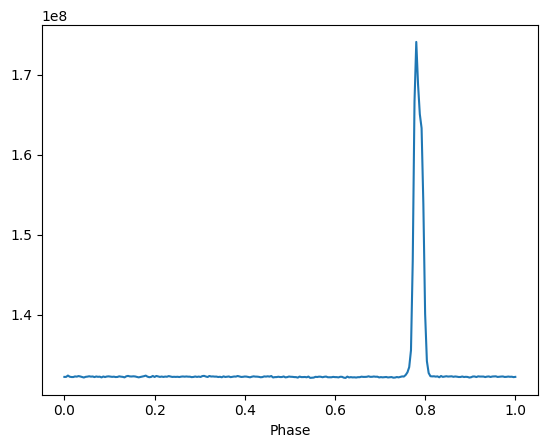

In [79]:
# you will see that there is a blank pixel near phase 0.5 and in the last time integration. 
# That is a bug from the observation itself and not your fault. Let's just zap it out for now
print(data.shape)
data = data[0:90,:]
print(data.shape)

# plot profile
xt = np.linspace(0, 1, nbin)
pulse_profile = data.sum(0)
plt.plot(xt, pulse_profile)
plt.xlabel("Phase")

In [179]:
# This next part is about solving the binary orbit. 
# I am very sorry in the original notebook I share on github and in the class, some cells and info are missing for this section !
# So you won't have been able to complete this notebook even if we didn't run out of time. 
# In particular, we need to download first a new data set that is of the binary pulsar J1810+1744, also taken by LOFAR
# It might take a while to complete the download (about 336 MB in total).

import requests
import os

api_url = "https://api.github.com/repos/cherryng/teaching/contents/Data_BinaryPulsar_J1810+1744"

res = requests.get(api_url)
files = res.json()

os.makedirs("data", exist_ok=True)

for file in files:
    if file["type"] == "file":
        download_url = file["download_url"]
        filename = file["name"]
        
        r = requests.get(download_url)
        with open(f"data/{filename}", "wb") as f:
            f.write(r.content)

print("Done downloading files")



Done downloading files


/opt/homebrew/Caskroom/miniconda/base/envs/vri/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/vri/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


56300.4688155539 601.4015927885233
56300.45492639893 601.3904954873194
56300.44103724313 601.3793981861156
56300.42714808649 601.357203583708
56300.413258929024 601.4071414391252
56300.39936977075 601.418238740329
56300.38548061164 601.4348846921347
56300.37159145176 601.4348846921347
56300.35770229113 601.4404333427366
56300.34381312978 601.4293360415328


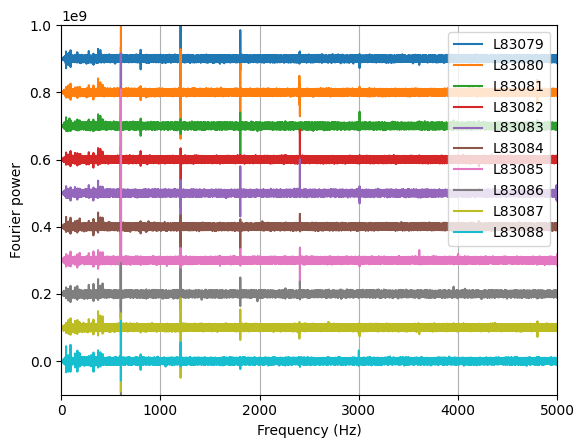

In [180]:
#This cell is going to find the spin frequency from each of the 10 observation files. 
#Each observation is taken at a different epoch (MJD). so each file is a snapshot of a specific orbital phase. 
#The observed spin freq will thus be varying and from that we can measure the orbital motion of this binary pulsar. 

from scipy.signal import find_peaks

tsamp=2.04799998755334e-05 #Sampling rate, it is in the .inf file. I am just hardcoding it here. 
target_f0 = 601.41151608175   #Found this from psrcat. this is the rest spin freq of this pulsar.
window = 1.0 #Hz    
#We will put the 10 pairs of spin freq and MJDs in the following two lists. 
f0s_fft = []
MJDs = [] 

def find_f0(INF, yoffset):
    FID=INF.split("_")[0]
    ts = np.fromfile("data/"+INF+".dat", dtype=np.float32)
    fft = np.fft.rfft(ts-scipy.ndimage.uniform_filter1d(ts, size=1000))[1:]
    xf = np.fft.rfftfreq(n=ts.size, d=tsamp)[1:]
    #I am using the y_offset just so that we can plot all ffts on the same plot without overlapping each other
    plt.plot(xf, fft+yoffset,label=str(FID))
    #Find the peak near 601
    mask = (xf > target_f0 - window) & (xf < target_f0 + window)
    idx_local = np.argmax(fft[mask])
    f0_fft = xf[mask][idx_local]
    #Read the MJD from the corresponding info file.
    with open("data/"+INF+".inf") as f:
        for line in f:
            if "MJD" in line and line.split():
                MJD = float(line.split()[-1])
    return f0_fft, MJD

f0_fft, MJD = find_f0("L83079_SAP0_BEAM0_DM39.66",0.9e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83080_SAP0_BEAM0_DM39.66",0.8e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83081_SAP0_BEAM0_DM39.66",0.7e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83082_SAP0_BEAM0_DM39.66",0.6e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83083_SAP0_BEAM0_DM39.66",0.5e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83084_SAP0_BEAM0_DM39.66",0.4e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83085_SAP0_BEAM0_DM39.66",0.3e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83086_SAP0_BEAM0_DM39.66",0.2e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83087_SAP0_BEAM0_DM39.66",0.1e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))
f0_fft, MJD = find_f0("L83088_SAP0_BEAM0_DM39.66",0e9)
print(MJD, f0_fft)
f0s_fft.append(float(f0_fft))
MJDs.append(float(MJD))

plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")
plt.xlim(-0.1, 5000)
plt.ylim(-0.1e9, 1e9)
plt.legend(loc=1)
plt.grid()


Guessed orbital period 0.1250024241162464 days
Scipy fitted orbital period is 0.1396513497841717 days


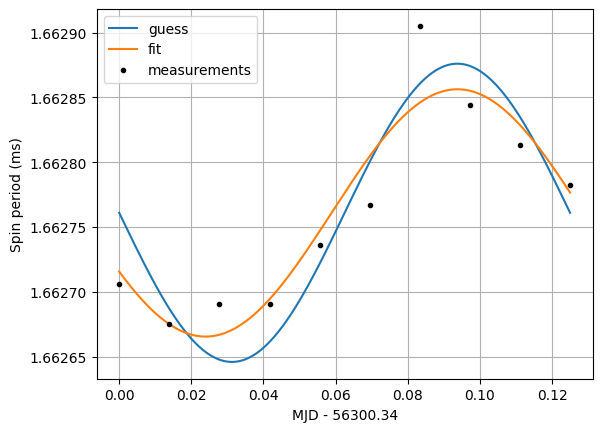

In [184]:
# fitting binary orbit

#Convert to spin periods
p0s = 1 / np.array(f0s_fft)

def binary_orbit(t, amp, pb, phase, offset):
    return amp * np.sin(2 * np.pi * (1 / pb) * t + phase) + offset

# This need to start at zero so we subtract np.min(mjd)
xt = np.linspace(np.min(MJDs), np.max(MJDs), 1000) - np.min(MJDs)

# Plot the data obtained
plt.errorbar(MJDs - np.min(MJDs), p0s * 1000, fmt=".", color="black",label='measurements')
# Try to guess the binary orbit, these are just guesses anyways to try and get close to the blue dots. they don't have to be these values
amp_guess = (np.max(p0s) - np.min(p0s)) / 2.
pb_guess = np.max(MJDs) - np.min(MJDs)
phase_guess = np.pi
offset_guess = np.mean(p0s)
#Feed these 5 input parameters to function(binary_orbit) to get a guess of the orbit
orbit_guess = binary_orbit(xt, amp_guess, pb_guess, phase_guess, offset_guess)
#print(amp_guess, pb_guess, phase_guess, offset_guess)
print('Guessed orbital period',pb_guess,'days')

plt.plot(xt, orbit_guess*1000, label="guess")

# Use scipy.optimize.curve_fit to fit to the data collected
import scipy.optimize
popt, pcov = scipy.optimize.curve_fit(binary_orbit, MJDs - np.min(MJDs), p0s)
#Feed the popt obtained to function(binary_orbit) to get a fit of the orbit
orbit_fitted = binary_orbit(xt, *popt)
plt.plot(xt, orbit_fitted*1000 , label="fit")
print('Scipy fitted orbital period is', popt[1],'days')

plt.legend()
plt.xlabel("MJD - {:.2f}".format(np.min(MJDs)))
plt.ylabel("Spin period (ms)")
plt.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.grid()

#Orbital period as found on psrcat is 0.1481702850 days.